# 03 - Experiments part2

## 1. Конфигурация, данные, загрузка моделей

In [ ]:
import os, random
import numpy as np
import pandas as pd
import torch, torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from transformers import WavLMModel
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME  = "microsoft/wavlm-large"
SAMPLE_RATE = 16_000
MAX_SECONDS = 6.0
MAX_SAMPLES = int(MAX_SECONDS * SAMPLE_RATE)
N_LAYERS, FEAT_DIM = 25, 1024
LABEL2IDX   = {"bonafide": 1, "spoof": 0}

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DATASET_2021_ROOT = "/kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021"
LA2021_ROOT  = f"{DATASET_2021_ROOT}/ASVspoof2021_LA_eval/ASVspoof2021_LA_eval"
LA2021_FLAC  = f"{LA2021_ROOT}/flac"
LA2021_KEYS  = f"{DATASET_2021_ROOT}/LA-keys-full/keys/LA/CM/trial_metadata.txt"
CKPT_ROOT_NEW = "/kaggle/input/datasets/kassandra23/chekpoints"

FEAT_DIR_EVAL = "/kaggle/working/features_eval2021"
os.makedirs(FEAT_DIR_EVAL, exist_ok=True)

def parse_2021_keys(path, subset_filter="eval"):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) < 8: continue
            subset = p[7]
            if subset_filter and subset != subset_filter: continue
            rows.append({"speaker": p[0], "file_id": p[1], "codec": p[2],
                         "transmission": p[3], "attack": p[4],
                         "label": p[5], "trim": p[6], "subset": subset})
    return pd.DataFrame(rows)

eval2021_df     = parse_2021_keys(LA2021_KEYS, subset_filter="eval")
eval2021_labels = eval2021_df["label"].map(LABEL2IDX).values

def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2 * 100, thresholds[idx]

def compute_full_metrics(labels, scores):
    eer, thr = compute_eer(labels, scores)
    auc = roc_auc_score(labels, scores) * 100
    preds = (scores >= thr).astype(int)
    return {
        "EER%": eer,
        "AUC%": auc,
        "Accuracy@EER_thr%": accuracy_score(labels, preds) * 100,
        "F1_bonafide@EER_thr%": f1_score(labels, preds, pos_label=1) * 100,
        "Precision_bonafide%": precision_score(labels, preds, pos_label=1, zero_division=0) * 100,
        "Recall_bonafide%": recall_score(labels, preds, pos_label=1) * 100,
    }


In [ ]:
class LinearProbe(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)
    def forward(self, x):
        return self.fc(x)

class WeightedSumProbe(nn.Module):
    def __init__(self, n_layers=N_LAYERS, feat_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier = nn.Linear(feat_dim, n_classes)
    def forward(self, x):
        w = torch.softmax(self.layer_weights, dim=0)
        out = (x * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)
        return self.classifier(out)
    def get_weights(self):
        return torch.softmax(self.layer_weights, dim=0).detach().cpu().numpy()

class WeightedSumMLPProbe(nn.Module):
    def __init__(self, n_layers=N_LAYERS, feat_dim=FEAT_DIM, hidden_dim=256, dropout=0.3, n_classes=2):
        super().__init__()
        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, n_classes))
    def forward(self, x):
        w = torch.softmax(self.layer_weights, dim=0)
        out = (x * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)
        return self.classifier(out)

class WeightedSumProbeEndToEnd(nn.Module):
    def __init__(self, model_name=MODEL_NAME, n_layers=N_LAYERS, feat_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(model_name)
        for p in self.wavlm.parameters():
            p.requires_grad_(False)
        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier = nn.Linear(feat_dim, n_classes)
    def forward(self, wavs):
        with torch.no_grad():
            out = self.wavlm(wavs, output_hidden_states=True)
            hidden = torch.stack(out.hidden_states, dim=1)
            pooled = hidden.mean(dim=2)
        w = torch.softmax(self.layer_weights, dim=0)
        agg = (pooled * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)
        return self.classifier(agg)

def evaluate_model_on_eval(model, feats, labels, model_type="weighted_sum", batch_size=512):
    model.eval()
    all_scores = []
    n = len(labels)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch = np.array(feats[start:end])
            if model_type == "baseline":
                batch_t = torch.tensor(batch[:, -1, :], dtype=torch.float32).to(DEVICE)
            else:
                batch_t = torch.tensor(batch, dtype=torch.float32).to(DEVICE)
            logits = model(batch_t)
            scores = F.softmax(logits, dim=1)[:, 1]
            all_scores.extend(scores.cpu().numpy())
    eer, thr = compute_eer(labels, np.array(all_scores))
    return eer, thr, np.array(all_scores)

probe_baseline = LinearProbe().to(DEVICE)
probe_baseline.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_probe.pt", map_location=DEVICE))
probe_baseline.eval()

probe_ws = WeightedSumProbe().to(DEVICE)
probe_ws.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_weighted_sum.pt", map_location=DEVICE))
probe_ws.eval()

probe_mlp = WeightedSumMLPProbe().to(DEVICE)
probe_mlp.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_weighted_sum_mlp.pt", map_location=DEVICE))
probe_mlp.eval()

rawboost_full = WeightedSumProbeEndToEnd().to(DEVICE)
rawboost_full.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_rawboost.pt", map_location=DEVICE))
probe_rawboost = WeightedSumProbe().to(DEVICE)
probe_rawboost.layer_weights.data = rawboost_full.layer_weights.data.clone()
probe_rawboost.classifier.load_state_dict(rawboost_full.classifier.state_dict())
probe_rawboost.eval()
del rawboost_full
torch.cuda.empty_cache()

## 2. Признаки eval2021 и оценка моделей (EER)

In [ ]:
class RawAudioDatasetEval(Dataset):
    def __init__(self, df, flac_dir):
        self.df = df.reset_index(drop=True)
        self.flac_dir = flac_dir
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
            wav = wav.mean(0)
            if sr != SAMPLE_RATE:
                wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
            if wav.numel() < MAX_SAMPLES:
                reps = MAX_SAMPLES // wav.numel() + 1
                wav = wav.repeat(reps)[:MAX_SAMPLES]
            else:
                wav = wav[:MAX_SAMPLES]
            label = LABEL2IDX[row.label]
        except Exception:
            wav, label = torch.zeros(MAX_SAMPLES), -1
        return wav, label, row.file_id

def collate_skip_corrupted(batch):
    wavs = torch.stack([b[0] for b in batch])
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    fids = [b[2] for b in batch]
    return wavs, labels, fids

eval2021_ds = RawAudioDatasetEval(eval2021_df, LA2021_FLAC)
eval2021_loader = DataLoader(eval2021_ds, batch_size=16, shuffle=False,
                             num_workers=2, pin_memory=True,
                             collate_fn=collate_skip_corrupted)

model = WavLMModel.from_pretrained(MODEL_NAME)
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)
print(f"WavLM загружен: {sum(p.numel() for p in model.parameters())/1e6:.1f}M параметров")

def extract_eval_features_streaming_amp(loader, save_prefix, n_total, n_layers=N_LAYERS, feat_dim=FEAT_DIM):
    feat_path  = f"{FEAT_DIR_EVAL}/{save_prefix}_features.npy"
    label_path = f"{FEAT_DIR_EVAL}/{save_prefix}_labels.npy"
    fid_path   = f"{FEAT_DIR_EVAL}/{save_prefix}_file_ids.npy"

    if os.path.exists(feat_path):
        feats = np.load(feat_path)
        labels_arr = np.load(label_path)
        fids_arr = np.load(fid_path, allow_pickle=True)
        print(f"{save_prefix}: загружено из кеша {feats.shape}")
        return feats, labels_arr, fids_arr

    feats_mm = np.lib.format.open_memmap(
        feat_path, mode="w+", dtype=np.float32, shape=(n_total, n_layers, feat_dim))

    all_labels, all_fids = [], []
    n_corrupted, write_idx = 0, 0

    with torch.no_grad():
        for wavs, labels, fids in tqdm(loader, desc=f"Extracting {save_prefix}"):
            wavs = wavs.to(DEVICE)
            with autocast('cuda', enabled=True):
                out = model(wavs, output_hidden_states=True)
                hidden = torch.stack(out.hidden_states, dim=1)
                pooled = hidden.mean(dim=2)

            batch_np = pooled.float().cpu().numpy()
            bsz = batch_np.shape[0]
            feats_mm[write_idx:write_idx + bsz] = batch_np
            write_idx += bsz

            all_labels.extend(labels.numpy().tolist())
            all_fids.extend(fids)
            n_corrupted += (labels == -1).sum().item()

    feats_mm.flush()
    labels_arr = np.array(all_labels)
    fids_arr = np.array(all_fids)
    valid_mask = labels_arr != -1

    if n_corrupted > 0:
        print(f"\n Повреждённых файлов: {n_corrupted}")
        valid_feats = np.array(feats_mm[valid_mask])
        del feats_mm
        np.save(feat_path, valid_feats)
        feats_final = valid_feats
    else:
        del feats_mm
        feats_final = np.load(feat_path)

    labels_final = labels_arr[valid_mask]
    fids_final = fids_arr[valid_mask]
    np.save(label_path, labels_final)
    np.save(fid_path, fids_final)

    print(f"{save_prefix}: сохранено {feats_final.shape}")
    return feats_final, labels_final, fids_final

n_total_eval = len(eval2021_df)
eval2021_feats, eval2021_labels, eval2021_fids = extract_eval_features_streaming_amp(
    eval2021_loader, "eval2021", n_total=n_total_eval)

del model
torch.cuda.empty_cache()
print(f"\neval2021_feats: {eval2021_feats.shape}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

WavLM загружен: 315.5M параметров


Extracting eval2021:   0%|          | 0/9261 [00:00<?, ?it/s]


⚠ Повреждённых файлов: 1


In [ ]:
eval2021_labels = eval2021_df["label"].map(LABEL2IDX).values
eval2021_fids   = np.load(f"{CKPT_ROOT_NEW}/eval2021_file_ids.npy", allow_pickle=True)

print(f"eval2021_labels: {eval2021_labels.shape}")
print(f"eval2021_fids  : {eval2021_fids.shape}")

eval2021_feats = np.load("/kaggle/working/features_eval2021/eval2021_features.npy", mmap_mode="r")
print(f"eval2021_feats : {eval2021_feats.shape}")

if eval2021_feats.shape[0] == len(eval2021_labels) == len(eval2021_fids):
    print("\n Все размеры совпадают")
else:
    print(f"\n Расхождение: feats={eval2021_feats.shape[0]}, "
          f"labels={len(eval2021_labels)}, fids={len(eval2021_fids)}")

fids_match = (eval2021_fids == eval2021_df["file_id"].values).all()
print(f"file_id порядок совпадает с eval2021_df: {fids_match}")

np.save("/kaggle/working/features_eval2021/eval2021_labels.npy", eval2021_labels)
print("\nlabels сохранены на диск")

eval2021_labels: (148176,)
eval2021_fids  : (148176,)
eval2021_feats : (148176, 25, 1024)

 Все размеры совпадают
file_id порядок совпадает с eval2021_df: True

labels сохранены на диск


In [ ]:
print("Оценка на eval2021:")

eer_baseline_2021, _, scores_baseline_2021 = evaluate_model_on_eval(
    probe_baseline, eval2021_feats, eval2021_labels, model_type="baseline")
print(f"Baseline: EER = {eer_baseline_2021:.3f}%")

eer_ws_2021, _, scores_ws_2021 = evaluate_model_on_eval(
    probe_ws, eval2021_feats, eval2021_labels, model_type="weighted_sum")
print(f"Weighted Sum + Linear: EER = {eer_ws_2021:.3f}%")

eer_mlp_2021, _, scores_mlp_2021 = evaluate_model_on_eval(
    probe_mlp, eval2021_feats, eval2021_labels, model_type="weighted_sum")
print(f"Weighted Sum + MLP: EER = {eer_mlp_2021:.3f}%")

eer_rb_2021, _, scores_rb_2021 = evaluate_model_on_eval(
    probe_rawboost, eval2021_feats, eval2021_labels, model_type="weighted_sum")
print(f"Weighted Sum + RawBoost : EER = {eer_rb_2021:.3f}%")

Оценка на eval2021:
Baseline: EER = 13.410%
Weighted Sum + Linear: EER = 6.904%
Weighted Sum + MLP: EER = 7.372%
Weighted Sum + RawBoost : EER = 7.519%


### Разбор EER по атакам, кодекам, каналам

In [18]:
def breakdown_by(df, scores, labels, group_col):
    d = df.copy().reset_index(drop=True)
    d["score"] = scores
    d["label_idx"] = labels
    bon = d["label"] == "bonafide"
    groups = sorted(d.loc[~bon, group_col].unique())
    rows = []
    for g in groups:
        sub = d[bon | (d[group_col] == g)]
        if sub["label_idx"].nunique() < 2:
            continue
        eer, _ = compute_eer(sub["label_idx"].values, sub["score"].values)
        rows.append({group_col: g, "EER%": eer, "n": (d[group_col] == g).sum()})
    return pd.DataFrame(rows).sort_values("EER%", ascending=False)

attack_breakdown       = breakdown_by(eval2021_df, scores_ws_2021, eval2021_labels, "attack")
codec_breakdown        = breakdown_by(eval2021_df, scores_ws_2021, eval2021_labels, "codec")
transmission_breakdown = breakdown_by(eval2021_df, scores_ws_2021, eval2021_labels, "transmission")
print(attack_breakdown.to_string(index=False))

attack      EER%     n
   A19 17.388530 10201
   A10 12.978266 10318
   A18  7.946658 10148
   A17  6.720934 10239
   A16  5.113387 10390
   A15  4.630649 10235
   A08  4.514639 10368
   A11  3.486658 10276
   A07  3.337365 10238
   A14  3.218644 10234
   A12  2.751293 10259
   A09  0.632433 10152
   A13  0.071096 10302


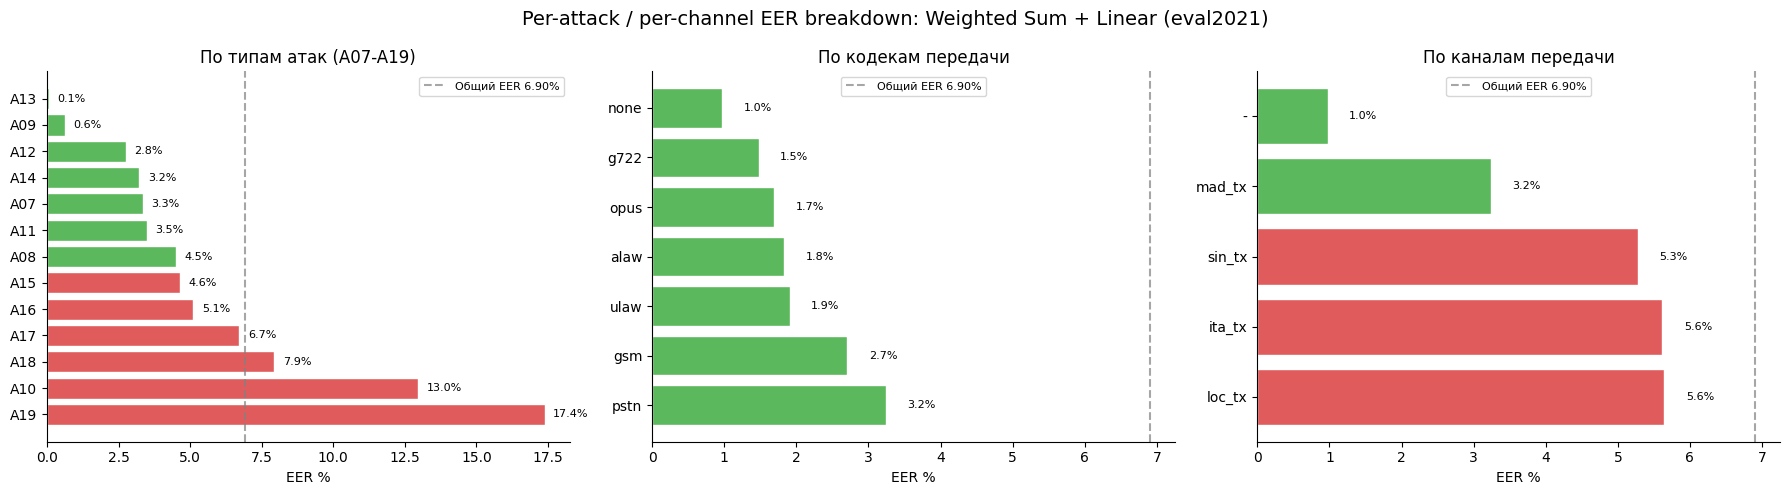

Самые сложные атаки: [['A19', 17.388530493876537], ['A10', 12.978266424671686], ['A18', 7.946657822754552]]
Самые простые атаки: [['A12', 2.751292812063875], ['A09', 0.6324334478773614], ['A13', 0.07109601587143716]]


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df_b, title, col) in zip(axes, [
    (attack_breakdown, "По типам атак (A07-A19)", "attack"),
    (codec_breakdown, "По кодекам передачи", "codec"),
    (transmission_breakdown, "По каналам передачи", "transmission"),
]):
    median_eer = attack_breakdown["EER%"].median()
    colors = ["#e05c5c" if e > median_eer else "#5cb85c" for e in df_b["EER%"]]
    bars = ax.barh(df_b[col].astype(str), df_b["EER%"], color=colors, edgecolor="white")
    for bar, val in zip(bars, df_b["EER%"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
                va="center", fontsize=8)
    ax.axvline(eer_ws_2021, linestyle="--", color="gray", alpha=0.7,
               label=f"Общий EER {eer_ws_2021:.2f}%")
    ax.set_xlabel("EER %")
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Per-attack / per-channel EER breakdown: Weighted Sum + Linear (eval2021)",
             fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/per_attack_breakdown_2021.png", dpi=150)
plt.show()

print("Самые сложные атаки:", attack_breakdown.head(3)[["attack","EER%"]].values.tolist())
print("Самые простые атаки:", attack_breakdown.tail(3)[["attack","EER%"]].values.tolist())

## 3. Официальный scoring: ASVspoof toolkit (min-tDCF)

In [20]:
import subprocess
result = subprocess.run(
    ["git", "clone", "https://github.com/asvspoof-challenge/2021.git", "/kaggle/working/asvspoof2021_repo"],
    capture_output=True, text=True)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-1000:] if result.stderr else "")

import os
eval_pkg = "/kaggle/working/asvspoof2021_repo/eval-package"
print(f"\n{eval_pkg} существует: {os.path.exists(eval_pkg)}")
if os.path.exists(eval_pkg):
    print("Содержимое:")
    for f in sorted(os.listdir(eval_pkg)):
        print(f"  {f}")


Cloning into '/kaggle/working/asvspoof2021_repo'...


/kaggle/working/asvspoof2021_repo/eval-package существует: True
Содержимое:
  ASVspoof2021_eval_notebook.ipynb
  README.md
  archived-package-stage-1
  config.py
  download.sh
  eval_metrics.py
  eval_wrapper.py
  main.py
  pd_tools.py
  table_API.py


In [23]:
import os

KEYS_DIR_FIXED = "/kaggle/working/keys_fixed"
os.makedirs(f"{KEYS_DIR_FIXED}/LA", exist_ok=True)
os.makedirs(f"{KEYS_DIR_FIXED}/PA", exist_ok=True)
os.makedirs(f"{KEYS_DIR_FIXED}/DF", exist_ok=True)

import subprocess
result = subprocess.run(
    ["cp", "-r", f"{DATASET_2021_ROOT}/LA-keys-full/keys/LA/.", f"{KEYS_DIR_FIXED}/LA/"],
    capture_output=True, text=True)
print("Copy LA:", result.returncode, result.stderr[-500:] if result.stderr else "")

print("\nСтруктура keys_fixed:")
for root, dirs, files in os.walk(KEYS_DIR_FIXED):
    depth = root[len(KEYS_DIR_FIXED):].count(os.sep)
    if depth > 2:
        dirs[:] = []
        continue
    print("  " * depth + os.path.basename(root) + "/")

Copy LA: 0 

Структура keys_fixed:
keys_fixed/
  PA/
  LA/
    ASV/
    CM/
  DF/


In [25]:
full_protocol_path = f"{KEYS_DIR_FIXED}/LA/CM/trial_metadata.txt"
with open(full_protocol_path) as f:
    all_lines = f.readlines()

print(f"Всего строк в оригинальном протоколе: {len(all_lines)}")

eval_lines = [line for line in all_lines if line.split()[-1] == "eval"]
print(f"Строк с subset='eval': {len(eval_lines)}")

backup_path = f"{KEYS_DIR_FIXED}/LA/CM/trial_metadata_full_backup.txt"
if not os.path.exists(backup_path):
    import shutil
    shutil.copy(full_protocol_path, backup_path)

with open(full_protocol_path, "w") as f:
    f.writelines(eval_lines)

print(f"\nПротокол перезаписан: только eval-записи ({len(eval_lines)} строк)")


Всего строк в оригинальном протоколе: 181566
Строк с subset='eval': 148176

Протокол перезаписан: только eval-записи (148176 строк)

Первый file_id в протоколе: LA_E_9332881
Первый file_id в score    : LA_E_9332881
Совпадают: True


In [ ]:
import re

def parse_tdcf_eer_output(stdout_text):
    tdcf_match = re.search(
        r"Table for min tDCFs\n=+\n.*?\\end\{tabular\}\n\n(.*?)\n\n\n",
        stdout_text, re.DOTALL)
    eer_match = re.search(
        r"Table for EERs\n=+\n.*?\\end\{tabular\}\n\n(.*?)\n\nPlease scroll",
        stdout_text, re.DOTALL)

    def parse_table_block(block_text):
        lines = [l for l in block_text.strip().split("\n") if l.strip()]
        header = lines[0].split()
        rows = []
        for line in lines[1:]:
            parts = line.split()
            attack = parts[0]
            values = [float(v) for v in parts[1:]]
            row = {"attack": attack}
            row.update(dict(zip(header, values)))
            rows.append(row)
        return pd.DataFrame(rows)

    tdcf_df = parse_table_block(tdcf_match.group(1)) if tdcf_match else None
    eer_df  = parse_table_block(eer_match.group(1))  if eer_match  else None
    return tdcf_df, eer_df

tdcf_df, eer_df = parse_tdcf_eer_output(result.stdout)

print("min t-DCF по атакам и условиям")
print(tdcf_df.to_string(index=False))
print("\nEER по атакам и условиям")
print(eer_df.to_string(index=False))

pooled_tdcf = tdcf_df[tdcf_df.attack == "Pooled"]["Pooled"].values[0]
pooled_eer  = eer_df[eer_df.attack == "Pooled"]["Pooled"].values[0]

print(f"\nPooled min-tDCF: {pooled_tdcf:.4f}")
print(f"Pooled EER:      {pooled_eer:.2f}%")

min t-DCF по атакам и условиям
attack     C1     C2     C3     C4     C5     C6     C7  Pooled
   A07 0.0640 0.1574 0.2635 0.0783 0.1645 0.2317 0.0723  0.2285
   A08 0.0757 0.1867 0.2846 0.0925 0.1920 0.2706 0.0813  0.2664
   A09 0.2405 0.3342 0.3728 0.2885 0.3289 0.3789 0.2883  0.3791
   A10 0.1008 0.2208 0.3737 0.1168 0.2226 0.2818 0.1378  0.4580
   A11 0.0650 0.1564 0.2709 0.0786 0.1633 0.2249 0.0723  0.2294
   A12 0.0647 0.1626 0.2439 0.0774 0.1680 0.2261 0.0698  0.2250
   A13 0.0615 0.1711 0.2672 0.0694 0.1763 0.2313 0.0601  0.1657
   A14 0.0592 0.1533 0.2499 0.0738 0.1579 0.2196 0.0654  0.2211
   A15 0.0628 0.1560 0.2363 0.0787 0.1633 0.2179 0.0690  0.2537
   A16 0.0692 0.1688 0.2466 0.0860 0.1737 0.2324 0.0814  0.2573
   A17 0.6967 0.7478 0.7271 0.7813 0.7079 0.6709 0.7296  0.7577
   A18 0.2212 0.4809 0.5483 0.2518 0.4981 0.5532 0.2436  0.6445
   A19 0.1683 0.4608 0.4702 0.1906 0.4851 0.5465 0.2361  0.7315
Pooled 0.1011 0.2333 0.3275 0.1219 0.2368 0.3125 0.1182  0.3428

EER по а

In [ ]:
def compute_official_metrics(scores, eval2021_df, model_name,
                              keys_dir=KEYS_DIR_FIXED, repo_dir="/kaggle/working/asvspoof2021_repo/eval-package"):
    score_path = f"/kaggle/working/{model_name}_score.txt"
    score_df = pd.DataFrame({
        "file_id": eval2021_df["file_id"].values,
        "score": scores
    })
    score_df.to_csv(score_path, sep=" ", header=False, index=False)

    result = subprocess.run(
        ["python", "main.py",
         "--cm-score-file", score_path,
         "--track", "LA",
         "--subset", "eval",
         "--metadata", keys_dir],
        cwd=repo_dir,
        capture_output=True, text=True
    )

    if result.returncode != 0 or "mismatch" in result.stdout:
        print(f"Ошибка для {model_name}:")
        print(result.stdout[:500])
        return None, None, result.stdout

    tdcf_df, eer_df = parse_tdcf_eer_output(result.stdout)
    if tdcf_df is None or eer_df is None:
        print(f" Не удалось распарсить вывод для {model_name}")
        return None, None, result.stdout

    pooled_tdcf = tdcf_df[tdcf_df.attack == "Pooled"]["Pooled"].values[0]
    pooled_eer  = eer_df[eer_df.attack == "Pooled"]["Pooled"].values[0]

    return pooled_eer, pooled_tdcf, result.stdout

print("Функция готова")

Функция готова


## 4. Fine-tuning T6–T12 на 100% данных

In [1]:
import os, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import WavLMModel
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "microsoft/wavlm-large"
SAMPLE_RATE = 16_000
MAX_SECONDS = 6.0
MAX_SAMPLES = int(MAX_SECONDS * SAMPLE_RATE)
LABEL2IDX = {"bonafide": 1, "spoof": 0}

set_seed(SEED)

DATASET_ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"
LA_ROOT      = f"{DATASET_ROOT}/LA/LA"
PROTO_DIR    = f"{LA_ROOT}/ASVspoof2019_LA_cm_protocols"
TRAIN_FLAC   = f"{LA_ROOT}/ASVspoof2019_LA_train/flac"
DEV_FLAC     = f"{LA_ROOT}/ASVspoof2019_LA_dev/flac"
PROTO_TRAIN  = f"{PROTO_DIR}/ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV    = f"{PROTO_DIR}/ASVspoof2019.LA.cm.dev.trl.txt"

def parse_protocol(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            rows.append({"file_id": p[1], "attack": p[3], "label": p[4]})
    return pd.DataFrame(rows)

train_df = parse_protocol(PROTO_TRAIN)
dev_df   = parse_protocol(PROTO_DEV)
WEIGHT_BONAFIDE = (train_df.label == "spoof").sum() / (train_df.label == "bonafide").sum()
print(f"train: {len(train_df):,}  dev: {len(dev_df):,}  WEIGHT_BONAFIDE={WEIGHT_BONAFIDE:.2f}")

train: 25,380  dev: 24,844  WEIGHT_BONAFIDE=8.84


In [6]:
class RawAudioDataset(Dataset):
    def __init__(self, df, flac_dir):
        self.df = df.reset_index(drop=True)
        self.flac_dir = flac_dir
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
        wav = wav.mean(0)
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
        if wav.numel() < MAX_SAMPLES:
            reps = MAX_SAMPLES // wav.numel() + 1
            wav = wav.repeat(reps)[:MAX_SAMPLES]
        else:
            wav = wav[:MAX_SAMPLES]
        return wav, LABEL2IDX[row.label]

FT_BATCH_SIZE = 16
ft_train_ds_100 = RawAudioDataset(train_df, TRAIN_FLAC)
ft_dev_ds_100   = RawAudioDataset(dev_df,   DEV_FLAC)
ft_train_loader_100 = DataLoader(ft_train_ds_100, batch_size=FT_BATCH_SIZE,
                                 shuffle=True, num_workers=2, pin_memory=True)
ft_dev_loader_100   = DataLoader(ft_dev_ds_100, batch_size=FT_BATCH_SIZE,
                                 shuffle=False, num_workers=2, pin_memory=True)
print(f"Train (100%): {len(ft_train_ds_100):,}")
print(f"Dev (100%):   {len(ft_dev_ds_100):,}")
print(f"train batches/epoch: {len(ft_train_loader_100)}")

Train (100%): 25,380
Dev (100%):   24,844
train batches/epoch: 1587


In [7]:
class FineTunedWavLM(nn.Module):
    def __init__(self, model_name=MODEL_NAME, unfreeze_layers=range(6, 13), n_classes=2):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(model_name)
        for p in self.wavlm.parameters():
            p.requires_grad_(False)
        self.unfrozen_idx = list(unfreeze_layers)
        for idx in self.unfrozen_idx:
            for p in self.wavlm.encoder.layers[idx].parameters():
                p.requires_grad_(True)
        self.classifier = nn.Linear(1024, n_classes)
    def forward(self, wavs):
        out = self.wavlm(wavs).last_hidden_state
        pooled = out.mean(dim=1)
        return self.classifier(pooled)

def run_epoch_ft(loader, model, criterion, optimizer=None, use_amp=True):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_labels, all_scores = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for wavs, labels in tqdm(loader, leave=False):
            wavs, labels = wavs.to(DEVICE), labels.to(DEVICE)
            with autocast('cuda', enabled=use_amp):
                logits = model(wavs)
                loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            scores = torch.softmax(logits.float(), dim=1)[:, 1]
            total_loss += loss.item() * len(labels)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.detach().cpu().numpy())
    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return total_loss / len(loader.dataset), eer

set_seed(SEED)
ft_model_100 = FineTunedWavLM(unfreeze_layers=range(6, 13)).to(DEVICE)
scaler = GradScaler('cuda')
opt_ft_100 = torch.optim.AdamW([
    {"params": [p for p in ft_model_100.wavlm.parameters() if p.requires_grad], "lr": 1e-5},
    {"params": ft_model_100.classifier.parameters(), "lr": 1e-3},
])
crit_ft_100 = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE))
sched_ft_100 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_ft_100, mode="min", factor=0.5, patience=1)

FT_NUM_EPOCHS, FT_PATIENCE = 5, 3
best_ft_eer_100, best_ft_epoch_100, ft_patience_cnt = float("inf"), -1, 0

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train EER':>10} {'Dev Loss':>10} {'Dev EER':>9}")
for epoch in range(1, FT_NUM_EPOCHS + 1):
    tr_loss, tr_eer = run_epoch_ft(ft_train_loader_100, ft_model_100, crit_ft_100, opt_ft_100)
    dv_loss, dv_eer = run_epoch_ft(ft_dev_loader_100, ft_model_100, crit_ft_100)
    sched_ft_100.step(dv_loss)
    marker = ""
    if dv_eer < best_ft_eer_100:
        best_ft_eer_100, best_ft_epoch_100, ft_patience_cnt = dv_eer, epoch, 0
        torch.save(ft_model_100.state_dict(), "/kaggle/working/best_finetuned_100pct.pt")
        marker = "  best"
    else:
        ft_patience_cnt += 1
    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_eer:>9.2f}% {dv_loss:>10.4f} {dv_eer:>8.2f}%{marker}",
          flush=True)
    if ft_patience_cnt >= FT_PATIENCE:
        print(f"Early stopping на эпохе {epoch}"); break

print(f"\nЛучший dev EER (fine-tuning T6-T12, 100% данных): {best_ft_eer_100:.2f}%  (эпоха {best_ft_epoch_100})")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

 Epoch  Train Loss  Train EER   Dev Loss   Dev EER


...

  0%|          | 0/1553 [00:00<?, ?it/s]

     3      0.0196      0.58%     0.4044     0.39%


  0%|          | 0/1587 [00:00<?, ?it/s]

  0%|          | 0/1553 [00:00<?, ?it/s]

     4      0.0129      0.40%     0.3206     0.39%
Early stopping на эпохе 4

Лучший dev EER (fine-tuning T6-T12, 100% данных): 0.25%  (эпоха 1)


In [8]:
import gc
del opt_ft_100, scaler
gc.collect()
torch.cuda.empty_cache()

DATASET_2021_ROOT = "/kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021"
LA2021_ROOT  = f"{DATASET_2021_ROOT}/ASVspoof2021_LA_eval/ASVspoof2021_LA_eval"
LA2021_FLAC  = f"{LA2021_ROOT}/flac"
LA2021_KEYS  = f"{DATASET_2021_ROOT}/LA-keys-full/keys/LA/CM/trial_metadata.txt"

eval2021_df = parse_2021_keys(LA2021_KEYS, subset_filter="eval")
print(f"eval2021_df: {len(eval2021_df):,} файлов")

eval2021_ds_raw = RawAudioDatasetEval(eval2021_df, LA2021_FLAC)
eval2021_loader_raw = DataLoader(eval2021_ds_raw, batch_size=16, shuffle=False,
                                 num_workers=2, pin_memory=True,
                                 collate_fn=collate_skip_corrupted)

def evaluate_raw_model_on_eval(model, loader):
    model.eval()
    all_labels, all_scores = [], []
    with torch.no_grad():
        for wavs, labels, fids in tqdm(loader, desc="FT-100% inference on eval2021"):
            valid = labels != -1
            if valid.sum() == 0:
                continue
            wavs_v = wavs[valid].to(DEVICE)
            with autocast('cuda', enabled=True):
                logits = model(wavs_v)
            scores = torch.softmax(logits.float(), dim=1)[:, 1]
            all_labels.extend(labels[valid].numpy())
            all_scores.extend(scores.cpu().numpy())
    eer, thr = compute_eer(np.array(all_labels), np.array(all_scores))
    return eer, thr, np.array(all_scores), np.array(all_labels)

eer_ft100_2021, thr_ft100, scores_ft100_2021, labels_ft100_2021 = evaluate_raw_model_on_eval(
    ft_model_100, eval2021_loader_raw)
print(f"\nFine-tuning T6-T12 (100% данных) на eval2021: EER = {eer_ft100_2021:.3f}%")

eval2021_df: 148,176 файлов


FT-100% inference on eval2021:   0%|          | 0/9261 [00:00<?, ?it/s]


Fine-tuning T6-T12 (100% данных) на eval2021: EER = 6.775%


In [9]:
print("ОБНОВЛЁННЫЙ ИТОГ: Fine-tuning T6-T12 на 100% данных")
print(f"Dev EER:      {best_ft_eer_100:.3f}%  (эпоха {best_ft_epoch_100})")
print(f"Eval2021 EER: {eer_ft100_2021:.3f}%")
print(f"\nСравнение с 30%-подвыборкой:")
print(f"  30%:  Dev=0.24%,  Eval2021=8.147%")
print(f"  100%: Dev={best_ft_eer_100:.3f}%, Eval2021={eer_ft100_2021:.3f}%")
print(f"\nУлучшение на eval2021: {8.147 - eer_ft100_2021:.3f} процентных пункта")

ОБНОВЛЁННЫЙ ИТОГ: Fine-tuning T6-T12 на 100% данных
Dev EER:      0.255%  (эпоха 1)
Eval2021 EER: 6.775%

Сравнение с 30%-подвыборкой:
  30%:  Dev=0.24%,  Eval2021=8.147%
  100%: Dev=0.255%, Eval2021=6.775%

Улучшение на eval2021: 1.372 процентных пункта


In [10]:
import subprocess

KEYS_DIR_FIXED = "/kaggle/working/keys_fixed"
if not os.path.exists(f"{KEYS_DIR_FIXED}/LA/CM/trial_metadata.txt"):
    os.makedirs(f"{KEYS_DIR_FIXED}/LA", exist_ok=True)
    os.makedirs(f"{KEYS_DIR_FIXED}/PA", exist_ok=True)
    os.makedirs(f"{KEYS_DIR_FIXED}/DF", exist_ok=True)
    subprocess.run(["cp", "-r", f"{DATASET_2021_ROOT}/LA-keys-full/keys/LA/.", f"{KEYS_DIR_FIXED}/LA/"])

    full_protocol_path = f"{KEYS_DIR_FIXED}/LA/CM/trial_metadata.txt"
    with open(full_protocol_path) as f:
        all_lines = f.readlines()
    eval_lines = [line for line in all_lines if line.split()[-1] == "eval"]
    with open(full_protocol_path, "w") as f:
        f.writelines(eval_lines)
    print(f"keys_fixed восстановлена, {len(eval_lines)} eval-записей")

repo_dir = "/kaggle/working/asvspoof2021_repo/eval-package"
if not os.path.exists(repo_dir):
    subprocess.run(["git", "clone", "https://github.com/asvspoof-challenge/2021.git",
                    "/kaggle/working/asvspoof2021_repo"])
    print("Репозиторий восстановлен")

keys_fixed восстановлена, 148176 eval-записей


Cloning into '/kaggle/working/asvspoof2021_repo'...


Репозиторий восстановлен


In [14]:
expected_labels = eval2021_df["label"].map(LABEL2IDX).values
print(f"Ожидается: {len(expected_labels)}, получено: {len(labels_ft100_2021)}")
diff = len(expected_labels) - len(labels_ft100_2021)
print(f"Разница: {diff} файл(ов)")

if diff == 1:
    mismatch_idx = None
    for i in range(len(labels_ft100_2021)):
        if expected_labels[i] != labels_ft100_2021[i]:
            mismatch_idx = i
            break
    if mismatch_idx is None:
        mismatch_idx = len(labels_ft100_2021)

    print(f"Пропущенный файл находится на позиции: {mismatch_idx}")
    print(f"file_id: {eval2021_df.iloc[mismatch_idx]['file_id']}")

    eval2021_df_aligned = eval2021_df.drop(eval2021_df.index[mismatch_idx]).reset_index(drop=True)
    print(f"\nНовый размер eval2021_df_aligned: {len(eval2021_df_aligned)}")
else:
    print("Разница не равна 1 — нужна другая логика")

Ожидается: 148176, получено: 148175
Разница: 1 файл(ов)
Пропущенный файл находится на позиции: 106385
file_id: LA_E_4938845

Новый размер eval2021_df_aligned: 148175


In [16]:
import shutil

KEYS_DIR_FT = "/kaggle/working/keys_fixed_ft"
if os.path.exists(KEYS_DIR_FT):
    shutil.rmtree(KEYS_DIR_FT)

shutil.copytree(KEYS_DIR_FIXED, KEYS_DIR_FT)

protocol_path_ft = f"{KEYS_DIR_FT}/LA/CM/trial_metadata.txt"
with open(protocol_path_ft) as f:
    lines = f.readlines()

print(f"Строк до фильтрации: {len(lines)}")
lines_filtered = [l for l in lines if "LA_E_4938845" not in l]
print(f"Строк после фильтрации: {len(lines_filtered)}")

with open(protocol_path_ft, "w") as f:
    f.writelines(lines_filtered)

print(f"\nKeys для fine-tuning готовы: {KEYS_DIR_FT}")

Строк до фильтрации: 148176
Строк после фильтрации: 148175

Keys для fine-tuning готовы: /kaggle/working/keys_fixed_ft


In [17]:
eer_ft100_official, tdcf_ft100_official, ft_stdout = compute_official_metrics(
    scores_ft100_2021, eval2021_df_aligned, "finetuning_100pct", keys_dir=KEYS_DIR_FT)

if eer_ft100_official is not None:
    print(f"Fine-tuning (100%) официальные метрики:")
    print(f"EER = {eer_ft100_official:.2f}%")
    print(f"min-tDCF = {tdcf_ft100_official:.4f}")
else:
    print("Не удалось посчитать, вывод скрипта:")
    print(ft_stdout[:1000])

Fine-tuning (100%) официальные метрики:
  EER = 6.78%
  min-tDCF = 0.3631


In [18]:
official_results = {
    "baseline":   {"EER%": 13.41, "min_tDCF": 0.5101},
    "ws_linear":  {"EER%": 6.90,  "min_tDCF": 0.3428},
    "ws_mlp":     {"EER%": 7.37,  "min_tDCF": 0.3413},
    "rawboost":   {"EER%": 7.52,  "min_tDCF": 0.3673},
    "finetuning": {"EER%": 6.78,  "min_tDCF": 0.3631},
}

official_df = pd.DataFrame(official_results).T.sort_values("EER%")
print(official_df.to_string())

official_df.to_csv("/kaggle/working/official_metrics_all_models.csv")
print("\nСохранено")

             EER%  min_tDCF
finetuning   6.78    0.3631
ws_linear    6.90    0.3428
ws_mlp       7.37    0.3413
rawboost     7.52    0.3673
baseline    13.41    0.5101

Сохранено


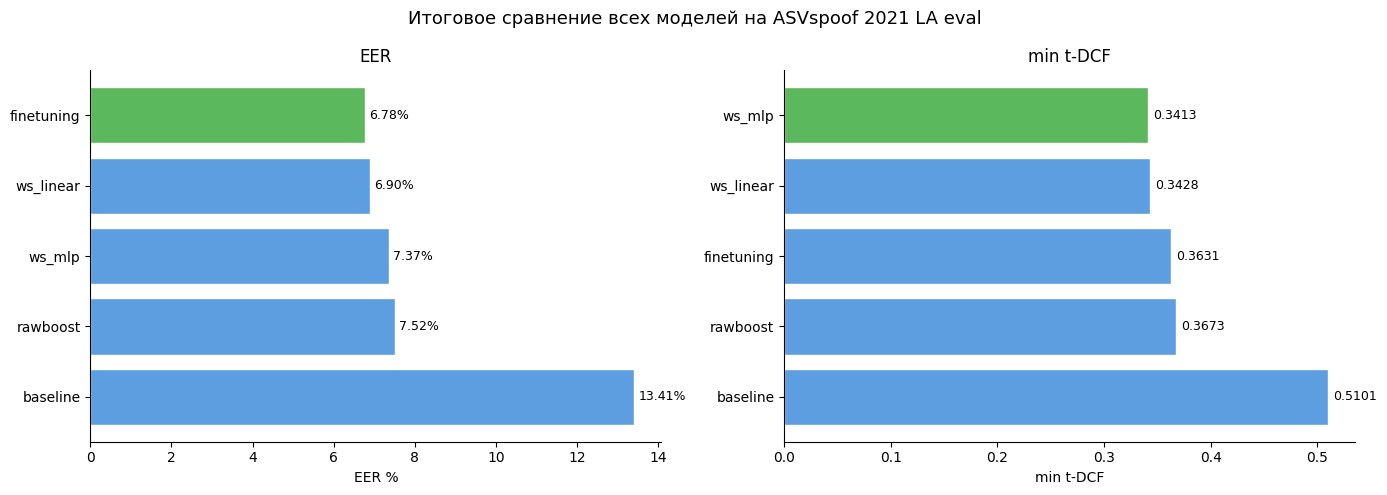

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_order = official_df.sort_values("EER%").index.tolist()
colors_eer = ["#5cb85c" if m == models_order[0] else "#5c9ee0" for m in models_order]

axes[0].barh(models_order, official_df.loc[models_order, "EER%"], color=colors_eer, edgecolor="white")
axes[0].set_xlabel("EER %")
axes[0].set_title("EER", fontsize=12)
axes[0].invert_yaxis()
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(official_df.loc[models_order, "EER%"]):
    axes[0].text(v + 0.1, i, f"{v:.2f}%", va="center", fontsize=9)

models_order_tdcf = official_df.sort_values("min_tDCF").index.tolist()
colors_tdcf = ["#5cb85c" if m == models_order_tdcf[0] else "#5c9ee0" for m in models_order_tdcf]
tdcf_vals = official_df.loc[models_order_tdcf, "min_tDCF"]

axes[1].barh(models_order_tdcf, tdcf_vals, color=colors_tdcf, edgecolor="white")
axes[1].set_xlabel("min t-DCF")
axes[1].set_title("min t-DCF", fontsize=12)
axes[1].invert_yaxis()
axes[1].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(tdcf_vals):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("Итоговое сравнение всех моделей на ASVspoof 2021 LA eval", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/final_official_comparison.png", dpi=150)
plt.show()

In [ ]:
def check_representativeness(full_df, subset_df, name, group_cols=("label", "attack", "codec", "transmission")):
    print(f"{name}: полный датасет ({len(full_df):,}) vs подвыборка ({len(subset_df):,})\n")

    for col in group_cols:
        if col not in full_df.columns:
            continue
        full_dist = full_df[col].value_counts(normalize=True).sort_index()
        subset_dist = subset_df[col].value_counts(normalize=True).sort_index()

        print(f"--- {col} ---")
        comparison = pd.DataFrame({
            "full_%": (full_dist * 100).round(2),
            "subset_%": (subset_dist * 100).round(2),
        })
        comparison["diff_pp"] = (comparison["subset_%"] - comparison["full_%"]).round(2)
        print(comparison.to_string())
        max_diff = comparison["diff_pp"].abs().max()
        print(f"Максимальное отклонение: {max_diff:.2f} процентных пункта\n")

t-SNE подвыборка (n=5000): полный датасет (148,176) vs подвыборка (5,000)

--- label ---
          full_%  subset_%  diff_pp
label                              
bonafide    10.0     10.96     0.96
spoof       90.0     89.04    -0.96
Максимальное отклонение: 0.96 процентных пункта

--- attack ---
          full_%  subset_%  diff_pp
attack                             
A07         6.91      7.24     0.33
A08         7.00      7.38     0.38
A09         6.85      6.74    -0.11
A10         6.96      6.62    -0.34
A11         6.93      6.92    -0.01
A12         6.92      7.62     0.70
A13         6.95      6.82    -0.13
A14         6.91      6.44    -0.47
A15         6.91      6.94     0.03
A16         7.01      6.72    -0.29
A17         6.91      6.78    -0.13
A18         6.85      6.50    -0.35
A19         6.88      6.32    -0.56
bonafide   10.00     10.96     0.96
Максимальное отклонение: 0.96 процентных пункта

--- codec ---
       full_%  subset_%  diff_pp
codec                          

## 5. Полный eval2021: метрики и t-SNE

In [31]:
FEAT_DIR_EVAL = "/kaggle/working/features_eval2021"
os.makedirs(FEAT_DIR_EVAL, exist_ok=True)

class RawAudioDatasetEvalFull(Dataset):
    def __init__(self, df, flac_dir):
        self.df = df.reset_index(drop=True)
        self.flac_dir = flac_dir
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
            wav = wav.mean(0)
            if sr != SAMPLE_RATE:
                wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
            if wav.numel() < MAX_SAMPLES:
                reps = MAX_SAMPLES // wav.numel() + 1
                wav = wav.repeat(reps)[:MAX_SAMPLES]
            else:
                wav = wav[:MAX_SAMPLES]
            label = LABEL2IDX[row.label]
        except Exception:
            wav, label = torch.zeros(MAX_SAMPLES), -1
        return wav, label, row.file_id

eval2021_ds_full = RawAudioDatasetEvalFull(eval2021_df, LA2021_FLAC)
eval2021_loader_full = DataLoader(eval2021_ds_full, batch_size=16, shuffle=False,
                                  num_workers=2, pin_memory=True,
                                  collate_fn=collate_skip_corrupted)

wavlm_model = WavLMModel.from_pretrained(MODEL_NAME)
wavlm_model.eval().to(DEVICE)
for p in wavlm_model.parameters():
    p.requires_grad_(False)

feat_path  = f"{FEAT_DIR_EVAL}/eval2021_features.npy"
n_total = len(eval2021_df)
feats_mm = np.lib.format.open_memmap(feat_path, mode="w+", dtype=np.float32, shape=(n_total, 25, 1024))

all_labels, all_fids = [], []
write_idx, n_corrupted = 0, 0

with torch.no_grad():
    for wavs, labels, fids in tqdm(eval2021_loader_full, desc="Extracting full eval2021"):
        wavs = wavs.to(DEVICE)
        with autocast('cuda', enabled=True):
            out = wavlm_model(wavs, output_hidden_states=True)
            hidden = torch.stack(out.hidden_states, dim=1)
            pooled = hidden.mean(dim=2)
        batch_np = pooled.float().cpu().numpy()
        bsz = batch_np.shape[0]
        feats_mm[write_idx:write_idx+bsz] = batch_np
        write_idx += bsz
        all_labels.extend(labels.numpy().tolist())
        all_fids.extend(fids)
        n_corrupted += (labels == -1).sum().item()

feats_mm.flush()
del wavlm_model, feats_mm
torch.cuda.empty_cache()

labels_arr = np.array(all_labels)
fids_arr = np.array(all_fids)
np.save(f"{FEAT_DIR_EVAL}/eval2021_labels.npy", labels_arr)
np.save(f"{FEAT_DIR_EVAL}/eval2021_file_ids.npy", fids_arr)

print(f"\nГотово. Повреждённых файлов: {n_corrupted}")
print(f"Признаки: {n_total} x 25 x 1024 сохранены в {feat_path}")

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Extracting full eval2021:   0%|          | 0/9261 [00:00<?, ?it/s]


Готово. Повреждённых файлов: 1
Признаки: 148176 x 25 x 1024 сохранены в /kaggle/working/features_eval2021/eval2021_features.npy


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

N_TSNE_LARGE = 15000

idx_all = np.arange(len(eval2021_df))
strat_labels = eval2021_df["label"].values

tsne_idx_large, _ = train_test_split(
    idx_all, train_size=N_TSNE_LARGE, stratify=strat_labels, random_state=SEED)

eval2021_df_tsne_large = eval2021_df.iloc[tsne_idx_large].reset_index(drop=True)

eval2021_feats_full = np.load(f"{FEAT_DIR_EVAL}/eval2021_features.npy", mmap_mode="r")
eval2021_labels_full = np.load(f"{FEAT_DIR_EVAL}/eval2021_labels.npy")

eval2021_feats_tsne_large = np.array(eval2021_feats_full[tsne_idx_large])
eval2021_labels_tsne_large = eval2021_labels_full[tsne_idx_large]

print(f"Подвыборка: {eval2021_feats_tsne_large.shape}")

check_representativeness(eval2021_df, eval2021_df_tsne_large, f"t-SNE подвыборка (n={N_TSNE_LARGE})")

Подвыборка: (15000, 25, 1024)
t-SNE подвыборка (n=15000): полный датасет (148,176) vs подвыборка (15,000)

--- label ---
          full_%  subset_%  diff_pp
label                              
bonafide    10.0      10.0      0.0
spoof       90.0      90.0      0.0
Максимальное отклонение: 0.00 процентных пункта

--- attack ---
          full_%  subset_%  diff_pp
attack                             
A07         6.91      7.14     0.23
A08         7.00      7.06     0.06
A09         6.85      6.75    -0.10
A10         6.96      7.11     0.15
A11         6.93      6.71    -0.22
A12         6.92      6.80    -0.12
A13         6.95      6.65    -0.30
A14         6.91      6.87    -0.04
A15         6.91      6.98     0.07
A16         7.01      6.67    -0.34
A17         6.91      7.19     0.28
A18         6.85      6.97     0.12
A19         6.88      7.10     0.22
bonafide   10.00     10.00     0.00
Максимальное отклонение: 0.34 процентных пункта

--- codec ---
       full_%  subset_%  diff_pp

In [33]:
with torch.no_grad():
    w_ws = torch.softmax(probe_ws.layer_weights, dim=0).cpu().numpy()

agg_embeddings_large = (eval2021_feats_tsne_large * w_ws[None, :, None]).sum(axis=1)
print(f"Агрегированные эмбеддинги: {agg_embeddings_large.shape}")
print("Запускаем t-SNE на 15000 точках")

tsne_large = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embeddings_2d_large = tsne_large.fit_transform(agg_embeddings_large)
print("t-SNE завершён")

Агрегированные эмбеддинги: (15000, 1024)
Запускаем t-SNE на 15000 точках


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE завершён


In [36]:
import torch.nn.functional as F

CKPT_ROOT_NEW = "/kaggle/input/datasets/kassandra23/chekpoints"

probe_baseline = LinearProbe().to(DEVICE)
probe_baseline.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_probe.pt", map_location=DEVICE))
probe_baseline.eval()

probe_mlp = WeightedSumMLPProbe().to(DEVICE)
probe_mlp.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_weighted_sum_mlp.pt", map_location=DEVICE))
probe_mlp.eval()

rawboost_full = WeightedSumProbeEndToEnd().to(DEVICE)
rawboost_full.load_state_dict(torch.load(f"{CKPT_ROOT_NEW}/best_rawboost.pt", map_location=DEVICE))
probe_rawboost = WeightedSumProbe().to(DEVICE)
probe_rawboost.layer_weights.data = rawboost_full.layer_weights.data.clone()
probe_rawboost.classifier.load_state_dict(rawboost_full.classifier.state_dict())
probe_rawboost.eval()
del rawboost_full
torch.cuda.empty_cache()

print("Все модели восстановлены")

eer_baseline_2021, _, scores_baseline_2021 = evaluate_model_on_eval(
    probe_baseline, eval2021_feats_full, eval2021_labels_full, model_type="baseline")
eer_ws_2021, _, scores_ws_2021 = evaluate_model_on_eval(
    probe_ws, eval2021_feats_full, eval2021_labels_full, model_type="weighted_sum")
eer_mlp_2021, _, scores_mlp_2021 = evaluate_model_on_eval(
    probe_mlp, eval2021_feats_full, eval2021_labels_full, model_type="weighted_sum")
eer_rb_2021, _, scores_rb_2021 = evaluate_model_on_eval(
    probe_rawboost, eval2021_feats_full, eval2021_labels_full, model_type="weighted_sum")

print(f"Baseline   : {eer_baseline_2021:.3f}%")
print(f"WS+Linear  : {eer_ws_2021:.3f}%")
print(f"WS+MLP     : {eer_mlp_2021:.3f}%")
print(f"RawBoost   : {eer_rb_2021:.3f}%")

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Все модели восстановлены
Baseline   : 13.410%
WS+Linear  : 6.904%
WS+MLP     : 7.372%
RawBoost   : 7.519%


### Итоговая таблица метрик

In [45]:
valid_mask = eval2021_labels_full != -1
print(f"Валидных файлов: {valid_mask.sum()} из {len(eval2021_labels_full)}")

eval2021_labels_clean = eval2021_labels_full[valid_mask]
scores_baseline_clean = scores_baseline_2021[valid_mask]
scores_ws_clean = scores_ws_2021[valid_mask]
scores_mlp_clean = scores_mlp_2021[valid_mask]
scores_rb_clean = scores_rb_2021[valid_mask]

all_metrics_eval2021 = {
    "baseline":   compute_full_metrics(eval2021_labels_clean, scores_baseline_clean),
    "ws_linear":  compute_full_metrics(eval2021_labels_clean, scores_ws_clean),
    "ws_mlp":     compute_full_metrics(eval2021_labels_clean, scores_mlp_clean),
    "rawboost":   compute_full_metrics(eval2021_labels_clean, scores_rb_clean),
    "finetuning": compute_full_metrics(labels_ft100_2021, scores_ft100_2021),
}

full_metrics_df = pd.DataFrame(all_metrics_eval2021).T

min_tdcf_official = {
    "baseline":   0.5101,
    "ws_linear":  0.3428,
    "ws_mlp":     0.3413,
    "rawboost":   0.3673,
    "finetuning": 0.3631,
}
full_metrics_df["min_tDCF"] = pd.Series(min_tdcf_official)

cols = ["EER%", "min_tDCF", "AUC%", "Accuracy@EER_thr%",
        "F1_bonafide@EER_thr%", "Precision_bonafide%", "Recall_bonafide%"]
full_metrics_df = full_metrics_df[cols]

print(full_metrics_df.round(4).to_string())
full_metrics_df.to_csv("/kaggle/working/full_metrics_eval2021.csv")
print("\nСохранено: full_metrics_eval2021.csv")

Валидных файлов: 148175 из 148176
               EER%  min_tDCF     AUC%  Accuracy@EER_thr%  F1_bonafide@EER_thr%  Precision_bonafide%  Recall_bonafide%
baseline    13.4100    0.5101  94.8576            86.5909               56.3578              41.7733           86.5888
ws_linear    6.9051    0.3428  98.3782            93.0947               72.9441              59.9644           93.0953
ws_mlp       7.3715    0.3413  98.3160            92.6276               71.5313              58.2612           92.6296
rawboost     7.5189    0.3673  98.1541            92.4812               71.0961              57.7437           92.4811
finetuning   6.7753    0.3631  98.2224            93.2256               73.3471              60.4570           93.2235

Сохранено: full_metrics_eval2021.csv


### t-SNE эмбеддингов (n=15000)

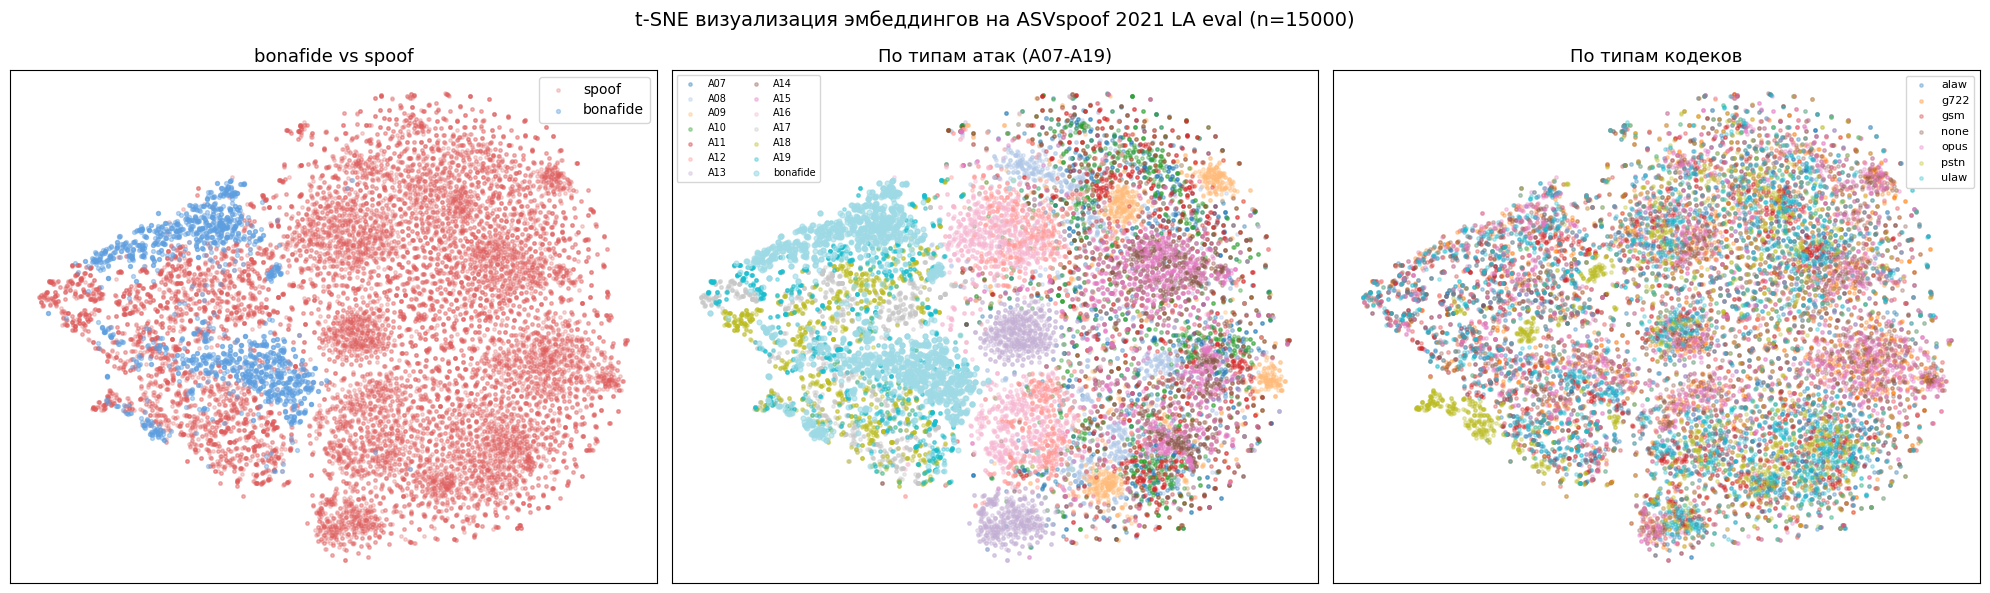

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mask_bon = eval2021_labels_tsne_large == 1
mask_spo = eval2021_labels_tsne_large == 0
axes[0].scatter(embeddings_2d_large[mask_spo, 0], embeddings_2d_large[mask_spo, 1],
               c="#e05c5c", alpha=0.25, s=6, label="spoof")
axes[0].scatter(embeddings_2d_large[mask_bon, 0], embeddings_2d_large[mask_bon, 1],
               c="#5c9ee0", alpha=0.4, s=8, label="bonafide")
axes[0].set_title(f"bonafide vs spoof", fontsize=13)
axes[0].legend()
axes[0].set_xticks([]); axes[0].set_yticks([])

attack_labels = eval2021_df_tsne_large["attack"].values
unique_attacks = sorted([a for a in np.unique(attack_labels) if a != "bonafide"]) + ["bonafide"]
attack_colors = plt.cm.tab20(np.linspace(0, 1, len(unique_attacks)))

for i, atk in enumerate(unique_attacks):
    mask = attack_labels == atk
    size = 12 if atk == "bonafide" else 6
    alpha = 0.6 if atk == "bonafide" else 0.35
    axes[1].scatter(embeddings_2d_large[mask, 0], embeddings_2d_large[mask, 1],
                    c=[attack_colors[i]], alpha=alpha, s=size, label=atk)
axes[1].set_title("По типам атак (A07-A19)", fontsize=13)
axes[1].legend(fontsize=7, loc="best", ncol=2)
axes[1].set_xticks([]); axes[1].set_yticks([])

codecs = sorted(eval2021_df_tsne_large["codec"].unique())
codec_colors = plt.cm.tab10(np.linspace(0, 1, len(codecs)))
for i, codec in enumerate(codecs):
    mask = (eval2021_df_tsne_large["codec"] == codec).values
    axes[2].scatter(embeddings_2d_large[mask, 0], embeddings_2d_large[mask, 1],
                    c=[codec_colors[i]], alpha=0.3, s=6, label=codec)
axes[2].set_title("По типам кодеков", fontsize=13)
axes[2].legend(fontsize=8, loc="best")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle(f"t-SNE визуализация эмбеддингов на ASVspoof 2021 LA eval (n={N_TSNE_LARGE})",
             fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/tsne_eval2021_full.png", dpi=150)
plt.show()